# Unemployment Analysis with Python

## Oasis Infobyte Data Science Internship

### Objective

The objective of this project is to analyze unemployment data in India using Python. This analysis helps in understanding unemployment trends across different states and regions through data cleaning, exploration, and visualization.

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

In [3]:
# ==========================================
# Load the Dataset
# ==========================================

# Read the CSV file
df = pd.read_csv("Unemployment in India.csv")

# Display the first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
# ==========================================
# Check the Shape of the Dataset
# ==========================================

print("Shape of the dataset:", df.shape)

Shape of the dataset: (768, 7)


In [5]:
# ==========================================
# Display Column Names
# ==========================================

print("Column Names:")
print(df.columns)

Column Names:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [6]:
# ==========================================
# Check Data Types
# ==========================================

print("Data Types:")
print(df.dtypes)

Data Types:
Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                            str
dtype: object


In [7]:
# ==========================================
# Check Missing Values
# ==========================================

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [8]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [9]:
# ==========================================
# Check Duplicate Rows
# ==========================================

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 27


In [10]:
# ==========================================
# Remove Missing Values
# ==========================================

df = df.dropna()

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64


In [11]:
# ==========================================
# Shape After Data Cleaning
# ==========================================

print("Shape after cleaning:", df.shape)

Shape after cleaning: (740, 7)


In [12]:
# ==========================================
# Save Cleaned Dataset
# ==========================================

df.to_csv("cleaned_unemployment_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


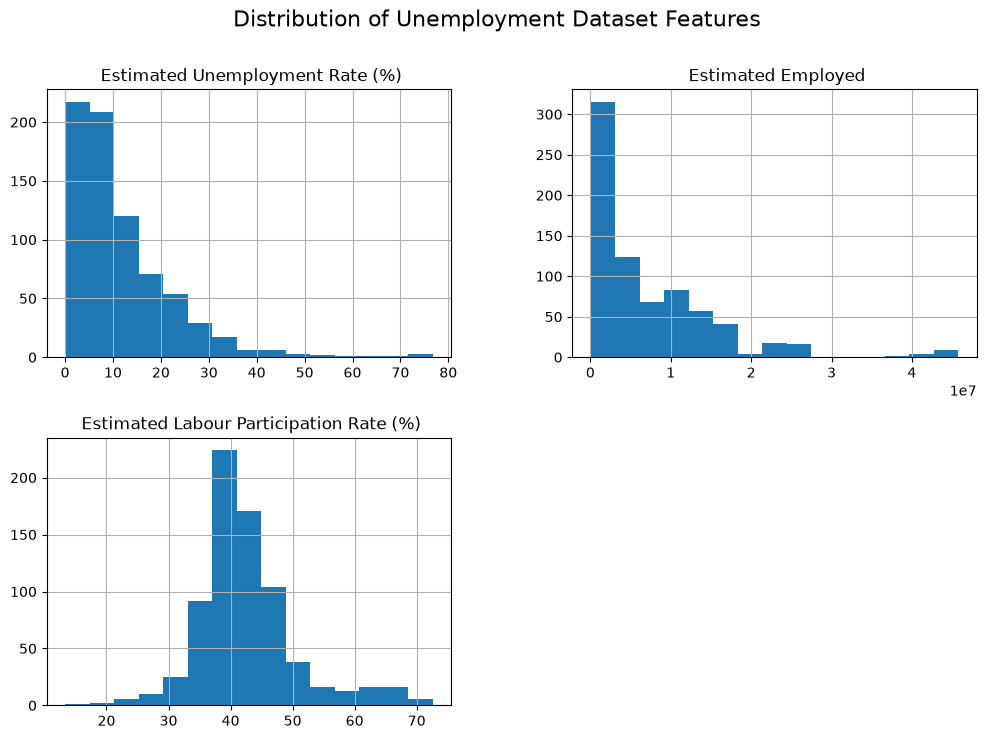

In [13]:
# ==========================================
# Distribution of Numerical Features
# ==========================================

df.hist(figsize=(12, 8), bins=15)

plt.suptitle("Distribution of Unemployment Dataset Features", fontsize=16)

plt.show()

In [15]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Display the cleaned column names
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


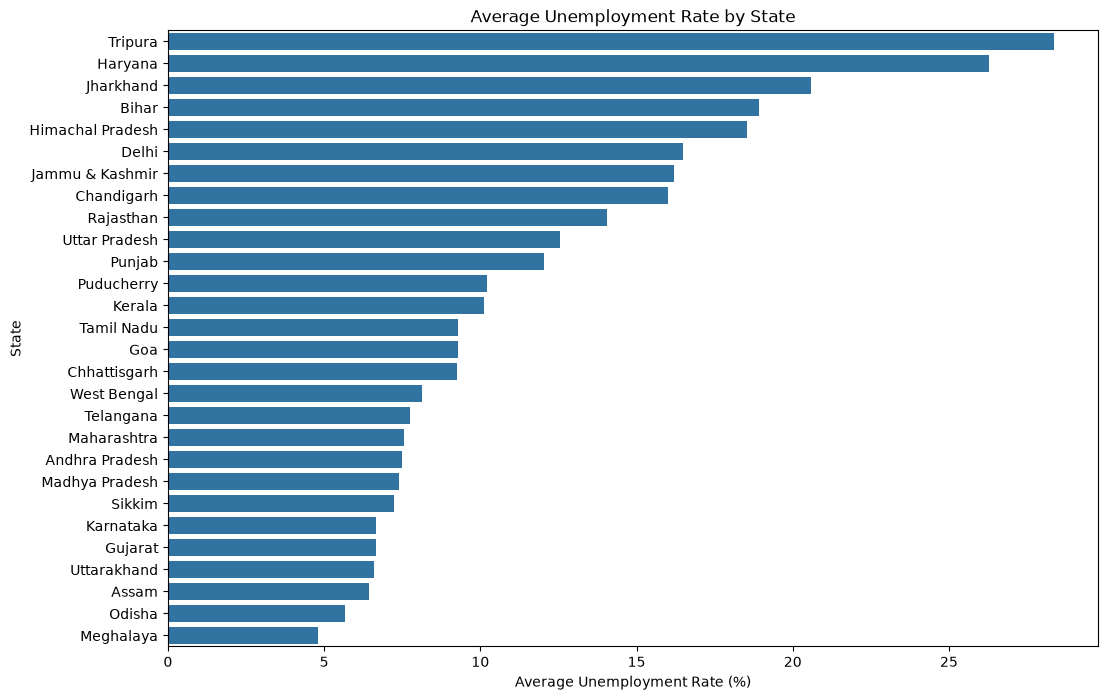

In [16]:
# ==========================================
# Average Unemployment Rate by State
# ==========================================

# Calculate average unemployment rate for each state
state_unemployment = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

# Create the plot
plt.figure(figsize=(12, 8))

sns.barplot(
    x=state_unemployment.values,
    y=state_unemployment.index
)

plt.title("Average Unemployment Rate by State")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

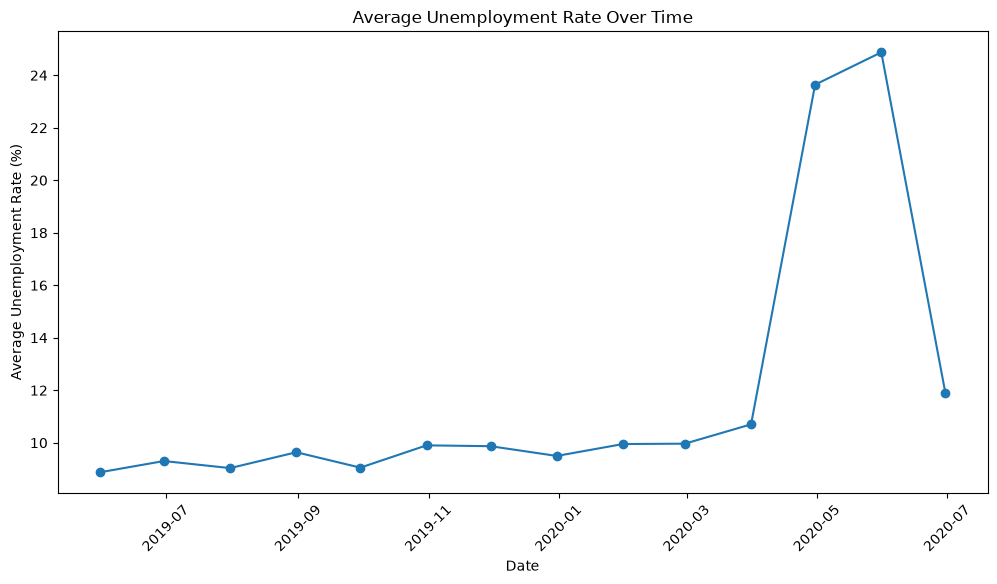

In [17]:
# ==========================================
# Monthly Unemployment Trend
# ==========================================

# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Calculate average unemployment rate by date
monthly_trend = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

# Plot the trend
plt.figure(figsize=(12,6))

plt.plot(monthly_trend.index, monthly_trend.values, marker="o")

plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

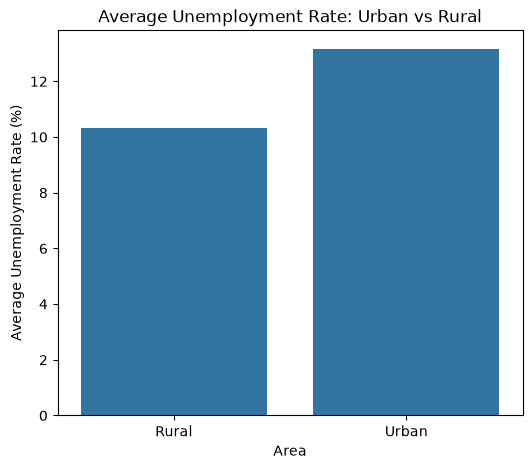

In [18]:
# ==========================================
# Urban vs Rural Unemployment Comparison
# ==========================================

# Calculate average unemployment rate by Area
area_unemployment = df.groupby("Area")["Estimated Unemployment Rate (%)"].mean()

# Plot
plt.figure(figsize=(6,5))

sns.barplot(
    x=area_unemployment.index,
    y=area_unemployment.values
)

plt.title("Average Unemployment Rate: Urban vs Rural")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

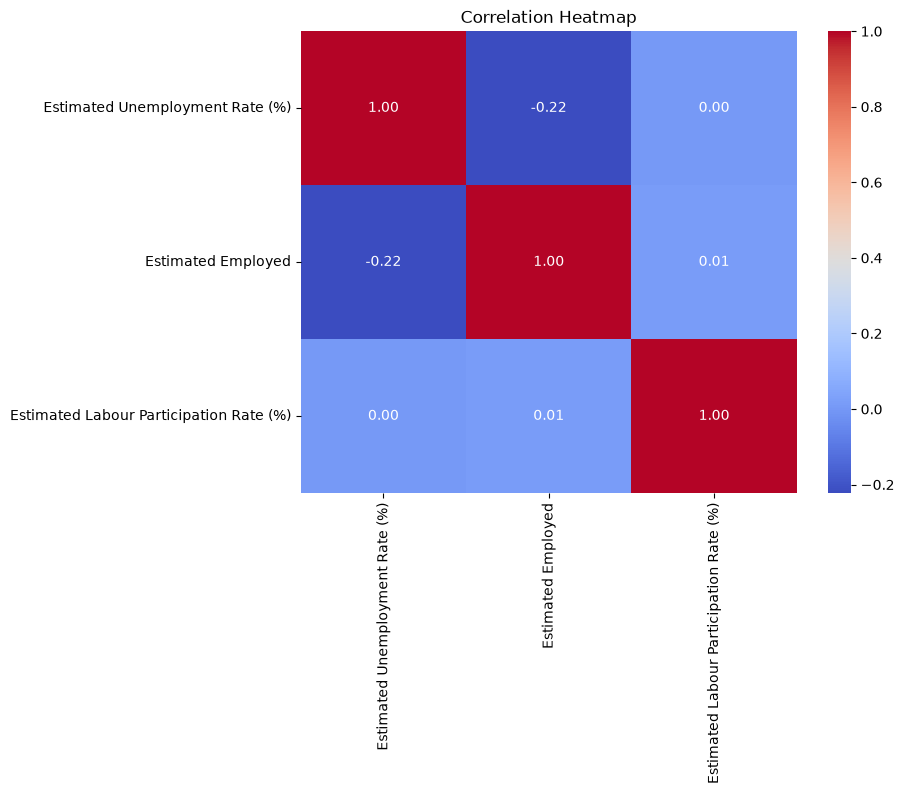

In [19]:
# ==========================================
# Correlation Heatmap
# ==========================================

# Select only numerical columns
numeric_df = df.select_dtypes(include=["number"])

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Observations

- The dataset contained missing values, which were removed during data cleaning.
- Unemployment rates vary significantly across different states.
- Some states have consistently higher average unemployment rates than others.
- The unemployment rate changes over time, showing fluctuations in different months.
- Urban and rural areas show differences in average unemployment rates.
- The correlation heatmap helps identify relationships between unemployment rate, employment, and labour participation rate.

# Conclusion

This project analyzed unemployment data in India using Python. The dataset was cleaned by removing missing values, and different visualizations were created to understand unemployment trends. The analysis showed variations in unemployment across states, changes over time, and differences between urban and rural areas. This project demonstrates how Python can be used for data cleaning, visualization, and extracting useful insights from real-world datasets.